# Funding-carry baseline — BTCUSDT 2024

Drive the C++ backtest from Python, establish an untuned baseline on real 2024 data (1-minute bars, real 8-hour funding), and split the equity curve into train / validation windows.

Setup, once per machine or after a clean build: create the env and build the module against its interpreter.

```
conda env create -f research/environment.yml
cmake --preset release -DQP_BUILD_PYTHON=ON \
  -DPYTHON_EXECUTABLE=$(conda run -n qp-research which python) \
  -DQP_PY_DATA_DIR=$PWD/data/binance_historical \
  -DQP_PY_FIRST_DAY=2024-01-01 -DQP_PY_LAST_DAY=2024-12-31
cmake --build build/release --target qp_backtest
```

Then select the `qp-research` kernel and Run All.

In [17]:
import os, sys, glob


def _module_dir():
    cands = []
    d = os.path.abspath(os.getcwd())
    while True:
        cands.append(os.path.join(d, "build", "release"))
        p = os.path.dirname(d)
        if p == d:
            break
        d = p
    cands.append(os.path.expanduser("~/quant-platform/build/release"))
    for c in cands:
        if glob.glob(os.path.join(c, "qp_backtest*.so")):
            return c
    raise RuntimeError("qp_backtest*.so not found; build: "
                       "cmake --build build/release --target qp_backtest")


sys.path.insert(0, _module_dir())
try:
    import qp_backtest as qb
except ImportError as e:
    raise ImportError(f"module found but won't load ({e}); the .so was built for a "
                      f"different Python than this kernel ({sys.version.split()[0]}). "
                      "Rebuild against this interpreter.") from e


def show(label, m):
    r2 = lambda d: {k: round(v, 2) for k, v in d.items()}
    print(label)
    print("  final equity:", round(m["final_equity"], 2), " points:", m["points"])
    print("  train:", r2(m["train"]))
    print("  val  :", r2(m["val"]))

import matplotlib.pyplot as plt

## Baseline

Default risk config, baseline.

default (max_drawdown=$50)
  final equity: -107.8  points: 1582216
  train: {'pnl': -107.8, 'max_drawdown': 107.8, 'sharpe': -1.81}
  val  : {'pnl': 0.0, 'max_drawdown': 0.0, 'sharpe': 0.0}


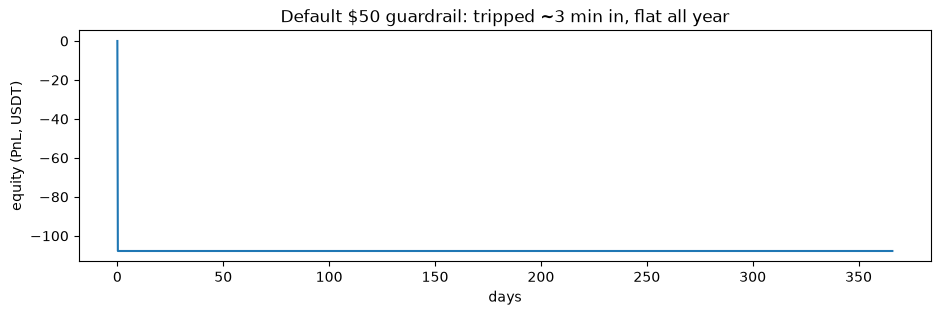

In [18]:
show("default (max_drawdown=$50)", qb.run_metrics())

s0 = qb.run_series(stride=1000)                      # default max_drawdown=$50
d0 = [(p.ts - s0[0].ts) / 86400e9 for p in s0]
plt.figure(figsize=(11, 3))
plt.plot(d0, [p.equity for p in s0])
plt.xlabel("days"); plt.ylabel("equity (PnL, USDT)")
plt.title("Default $50 guardrail: tripped ~3 min in, flat all year")
plt.show()

It loses ~$108 and the validation window is dead flat (zero PnL, zero drawdown), because the strategy trips its kill switch about three minutes in. The default max_drawdown = $50 can't survive one delta-neutral entry on a ~$50k BTC position (the legs don't offset perfectly intraday): the first mark-to-market noise flattens the book and it never trades again. One instant loss, not a year of bleeding. A mis-set guardrail, not the strategy's real behaviour.

## Strategy edge, guardrail lifted

Lift the kill switch to see the raw behaviour of the untuned thresholds. The carry's natural mark-to-market drawdown is a few thousand dollars on a 1-BTC position (the legs don't offset perfectly intraday), so a live guardrail must sit above that swing to protect against catastrophe without killing normal operation.

In [19]:
risk = qb.RiskConfig()
risk.max_drawdown = 1e12  # kill switch effectively off
baseline = qb.run_metrics(risk=risk)
show("edge (kill switch lifted)", baseline)
natural_dd = max(baseline["train"]["max_drawdown"], baseline["val"]["max_drawdown"])
print(f"  natural MTM drawdown ~${natural_dd:,.0f} -> set a live guardrail above this")

edge (kill switch lifted)
  final equity: 6551.22  points: 1582216
  train: {'pnl': 4316.92, 'max_drawdown': 3412.24, 'sharpe': 0.14}
  val  : {'pnl': 2234.31, 'max_drawdown': 5357.62, 'sharpe': 0.13}
  natural MTM drawdown ~$5,358 -> set a live guardrail above this


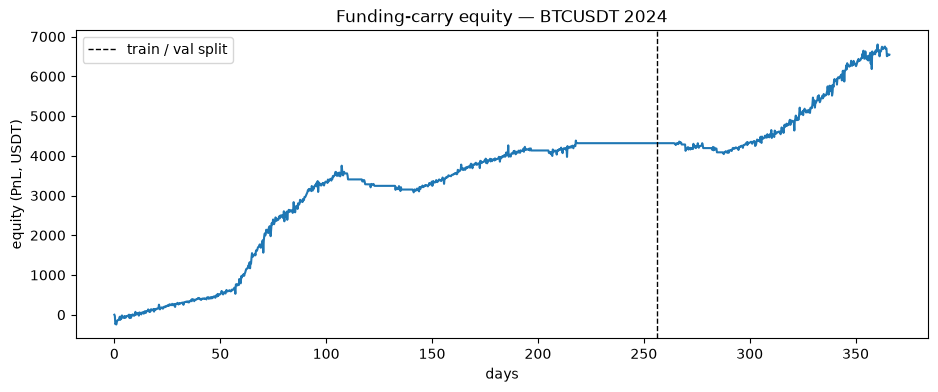

In [20]:
s = qb.run_series(risk=risk, stride=1000)
t0 = s[0].ts
days = [(p.ts - t0) / 86400e9 for p in s]
split = int(len(s) * 0.7)

plt.figure(figsize=(11, 4))
plt.plot(days, [p.equity for p in s])
plt.axvline(days[split], color="k", ls="--", lw=1, label="train / val split")
plt.xlabel("days"); plt.ylabel("equity (PnL, USDT)"); plt.legend()
plt.title("Funding-carry equity — BTCUSDT 2024")
plt.show()

Sharpe ratio is the return divided by the volatility of that return, annualised: profit earned per unit of wobble, where higher is smoother. Rough rule of thumb, under 1 is weak, 1 to 2 is decent, above 2 is strong. At ~0.13 the profit is tiny next to how much the equity swings, so the climb to +$6,551 was noisy, not a steady drip. It matters because two strategies can make the same money while one is calm and the other a rollercoaster, and only the calm one survives leverage, sizing, and your own nerves.

Drawdown is how far equity falls from a previous peak, and max drawdown is the worst such fall over the run. Here it is $5,358 in validation: at the worst moment we were $5.4k below our best. It matters because it is the loss you actually have to sit through to collect the profit, and it sets both the capital you must hold and where the kill switch belongs. A strategy whose ordinary drawdown is larger than you can stomach is unrunnable, however good the final number looks.

Lift the guardrail and the same strategy makes +$6,551, positive in both windows (train +$4,317, validation +$2,234). The edge holds on the held-out data, not just the stretch we would tune on. That is the signal worth chasing.

The quality is thin, though. Sharpe is ~0.13, and it took a $5,358 drawdown in validation to earn that: a weak return for the risk. The flat shelf near the split is a low-funding stretch holding no position, dead capital rather than a loss. One symbol, one untuned year, so treat this as proof there is something real to improve, not a result. A live guardrail belongs above the ~$5.4k natural drawdown; tuning entry, exit and size is where the return-for-risk should improve.